# 🚕 NYC HVFHV Taxi Demand-Supply Imbalance Prediction

**Project**: Predict demand-supply imbalance for driver reallocation  
**Data**: NYC High Volume FHV (HVFHV) trip records 2023–2025 (Parquet)  
**Aggregation**: 30-minute sliding window, sliding every 5 minutes  
**Grain**: `(zone_id, window_end_time)`

---
## Section 1 — Setup

In [1]:
# ─── Standard Library ────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

# ─── PySpark ─────────────────────────────────────────────────────────────────
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql.functions import count, when, col


# ─── Data / ML ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import lightgbm as lgb

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, r2_score
)
from sklearn.preprocessing import label_binarize

# ─── Visualisation ────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
PALETTE = sns.color_palette('tab10')

print('All imports OK')

All imports OK


In [2]:
# ─── Spark Session ────────────────────────────────────────────────────────────
spark = (
    SparkSession.builder
    .appName('NYC_HVFHV_Demand_Supply')

    # Core
    .master("local[*]")

    # Memory (quan trọng)
    .config("spark.driver.memory", "8g")
    .config("spark.driver.maxResultSize", "4g")

    # Shuffle tuning (RẤT QUAN TRỌNG)
    .config("spark.sql.shuffle.partitions", "64")

    # Adaptive Query Execution
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")

    # Parquet handling
    .config("spark.sql.parquet.mergeSchema", "false")
    .config("spark.sql.parquet.filterPushdown", "true")

    # Timezone
    .config("spark.sql.session.timeZone", "America/New_York")

    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')
print(f'Spark version: {spark.version}')

Spark version: 3.5.7


In [3]:
BRONZE_PATH = 'datasets/fvhfv/*'
schema = StructType([
    StructField("hvfhs_license_num", StringType(), True),
    StructField("dispatching_base_num", StringType(), True),
    StructField("originating_base_num", StringType(), True),
    StructField("PULocationID", IntegerType(), True),
    StructField("DOLocationID", IntegerType(), True),
    StructField("request_datetime", TimestampNTZType(), True),
    StructField("pickup_datetime", TimestampNTZType(), True),
    StructField("dropoff_datetime", TimestampNTZType(), True),
    StructField("trip_miles", DoubleType(), True),
    StructField("trip_time", LongType(), True),
    StructField("base_passenger_fare", DoubleType(), True),
    StructField("driver_pay", DoubleType(), True),
    StructField("tips", DoubleType(), True),
    StructField("congestion_surcharge", DoubleType(), True),
    StructField("airport_fee", DoubleType(), True),
    StructField("tolls", DoubleType(), True),
    StructField("bcf", DoubleType(), True),
    StructField("sales_tax", DoubleType(), True),
    StructField("shared_match_flag", StringType(), True),
    StructField("shared_request_flag", StringType(), True),
    StructField("on_scene_datetime", TimestampNTZType(), True),
    StructField("access_a_ride_flag", StringType(), True),
    StructField("wav_request_flag", StringType(), True),
    StructField("wav_match_flag", StringType(), True)
])
df = (
    spark.read
    # .schema(schema)
    .parquet(BRONZE_PATH)
)
df.count(), len(df.columns)

(264530057, 25)

In [4]:
trip = df.select(
    col("PULocationID").cast("long"),
    col("DOLocationID").cast("long"),
    col("request_datetime"),
    col("pickup_datetime"),
    col("dropoff_datetime"),
    col("trip_miles").cast("double"),
    col("trip_time").cast("long"),
    col("base_passenger_fare").cast("double"),
    col("driver_pay").cast("double"),
    col("tips").cast("double"),
    col("congestion_surcharge").cast("double"),
    col("airport_fee").cast("double"),
    col("tolls").cast("double"),
    col("bcf").cast("double"),
    col("sales_tax").cast("double"),
    col("shared_match_flag").alias("share_match_flag"),
    col("shared_request_flag").alias("share_request_flag"),
    col("wav_request_flag"),
    col("access_a_ride_flag"),
    col("wav_match_flag"),
    col("hvfhs_license_num"),
    col("cbd_congestion_fee")
)

In [5]:
null_stats = trip.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in trip.columns
])

# null_stats.show()

In [6]:
# trip.describe().show()

In [7]:
# trip.groupby("wav_match_flag") \
#     .count().show()

In [8]:
# trip.where("tips ==0").show(10, truncate=False)
# trip.where("tips ==0").count()

In [9]:
schemas = {}

for f in trip.inputFiles():
    df = spark.read.parquet(f)
    schemas[f] = df.schema.simpleString()

# group theo schema
from collections import defaultdict

groups = defaultdict(list)

for f, s in schemas.items():
    groups[s].append(f)

print(f"Total different schemas: {len(groups)}")

for i, (schema, files) in enumerate(groups.items()):
    print(f"\n--- Schema group {i+1} ({len(files)} files) ---")
    print(schema)

Total different schemas: 1

--- Schema group 1 (13 files) ---
struct<hvfhs_license_num:string,dispatching_base_num:string,originating_base_num:string,request_datetime:timestamp_ntz,on_scene_datetime:timestamp_ntz,pickup_datetime:timestamp_ntz,dropoff_datetime:timestamp_ntz,PULocationID:int,DOLocationID:int,trip_miles:double,trip_time:bigint,base_passenger_fare:double,tolls:double,bcf:double,sales_tax:double,congestion_surcharge:double,airport_fee:double,tips:double,driver_pay:double,shared_request_flag:string,shared_match_flag:string,access_a_ride_flag:string,wav_request_flag:string,wav_match_flag:string,cbd_congestion_fee:double>


## Section 1.5 -- Clean data

In [10]:
trips = trip.where("base_passenger_fare > 0 and driver_pay > 0 and trip_miles < 500 and trip_time < 20000 and driver_pay < 1500 ")
trips.count()

263987537

---
## Section 2 — Feature Engineering (Spark)

In [11]:
# ─── Window Configuration ─────────────────────────────────────────────────────
WINDOW_SECONDS = 30 * 60   # 30 min in seconds
SLIDE_SECONDS  =  10 * 60   # 10 min  in seconds

def epoch_to_window_end(ts_col: str, window_s: int = WINDOW_SECONDS, slide_s: int = SLIDE_SECONDS):
    """
    Assign each timestamp to the next (future) window boundary.
    window_end = ceil(ts / slide) * slide  — snaps to the next slide boundary.
    Spark's window() function handles this natively.
    """
    return F.window(F.col(ts_col), f'{window_s} seconds', f'{slide_s} seconds')

flag = lambda c: F.when(F.col(c) == "Y", 1).otherwise(0)
is_uber = F.when(F.col("hvfhs_license_num") == "HV0003", 1).otherwise(0)
print('Window helpers defined')

Window helpers defined


In [12]:
demand = (
    trips
    .withColumn("zone_id", F.col("PULocationID"))
    .withColumn("window", epoch_to_window_end("request_datetime"))
    .groupBy("zone_id", "window")
    .agg(
        # volume
        F.count("*").alias("requests_30m"),
        F.sum(
            F.when(
                F.col("request_datetime") >= F.col("window.end") - F.expr(f"INTERVAL {SLIDE_SECONDS} seconds"),
                1
            ).otherwise(0)
        ).alias("requests_10m"),

        # WAV / AAR (request-time)
        F.sum(flag("wav_request_flag")).alias("wav_req"),
        F.sum(flag("access_a_ride_flag")).alias("aar_req"),
        F.sum(flag("share_request_flag")).alias("share_req"),

        # platform share
        F.sum(is_uber).alias("uber_req"),
    )
    .withColumn("window_end", F.col("window.end"))
    .drop("window")
).where("zone_id <= 263 and window_end < '2026-01-31 23:00:00' and window_end >= '2025-01-05 08:00:00'")


In [13]:
pickup = (
    trips
    .withColumn("zone_id", F.col("PULocationID"))
    .withColumn("window", epoch_to_window_end("pickup_datetime"))
    .withColumn(
        "pickup_delay_s",
        F.unix_timestamp("pickup_datetime") - F.unix_timestamp("request_datetime")
    )
    .groupBy("zone_id", "window")
    .agg(
        # volume
        F.count("*").alias("pickup_30m"),
        F.sum(
            F.when(
                F.col("pickup_datetime") >= F.col("window.end") - F.expr(f"INTERVAL {SLIDE_SECONDS} seconds"),
                1
            )
        ).alias("pickup_10m"),

        # delay
        F.mean("pickup_delay_s").alias("pickup_delay_mean"),
        F.stddev("pickup_delay_s").alias("pickup_delay_std"),
        
        # matching (proxy)
        F.sum(
            F.when(col('request_datetime') >= col('window.start') , 1).otherwise(0)
        ).alias('matched_rp'),
        
        F.sum(
            F.when(((col('request_datetime') >= col('window.start') )
                   & (F.col("pickup_datetime") >= (F.col("window.end") - F.expr(f"INTERVAL {SLIDE_SECONDS} seconds")))), 1).otherwise(0)
        ).alias('matched_rp_10m'),

        # WAV match
        F.sum(flag("wav_match_flag")).alias("wav_match"),
        F.sum(flag("share_match_flag")).alias("share_match"),

    )
    .withColumn("window_end", F.col("window.end"))
    .drop("window")
).where("zone_id <= 263 and window_end < '2026-01-31 23:00:00' and window_end >= '2025-01-05 08:00:00'")
# pickup.printSchema(), pickup.show(5, truncate=False), pickup.count()
# pickup.select(F.min("window_end"), F.max("window_end")).show()

In [14]:
dropoff_counts = (
    trips
    .withColumn("zone_id", F.col("DOLocationID"))
    .withColumn("window", epoch_to_window_end("dropoff_datetime"))
    .groupBy("zone_id", "window")
    .agg(
        F.count("*").alias("dropoff_30m"),
        F.sum(
            F.when(
                F.col("dropoff_datetime") >= F.col("window.end") - F.expr(f"INTERVAL {SLIDE_SECONDS} seconds"),
                1
            )
        ).alias("dropoff_10m"),
        
        F.sum(
            F.when(((col('request_datetime') >= col('window.start'))), 1).otherwise(0)
        ).alias('matched_rd'),
        
    )
    .withColumn("window_end", F.col("window.end"))
    .drop("window")
).where("zone_id <= 263 and window_end < '2026-01-31 23:00:00' and window_end >= '2025-01-05 08:00:00'")
# dropoff_counts.printSchema(), dropoff_counts.show(5, truncate=False), dropoff_counts.count()
# dropoff_counts.select(F.min("window_end"), F.max("window_end")).show()

In [15]:
trips_valid = trips.filter(
    F.col("trip_miles").between(0.3, 500) &
    F.col("trip_time").between(200, 20000) &
    F.col("base_passenger_fare").between(1, 1500) &
    F.col("driver_pay").between(1, 1500)
)

dropoff_stats = (
    trips_valid
    .withColumn("zone_id", F.col("PULocationID"))
    .withColumn("window", epoch_to_window_end("dropoff_datetime"))
    .groupBy("zone_id", "window")
    .agg(
        F.mean('trip_time').alias('avg_trip_time'),
        # Price
        F.mean('base_passenger_fare').alias('avg_fare'),
        F.mean('driver_pay').alias('avg_driver_pay'),
        F.mean('tips').alias('avg_tips'),
        F.mean('bcf').alias('avg_bcf'),
        F.mean('tolls').alias('avg_tolls'),
        F.mean('congestion_surcharge').alias('avg_congestion_surcharge'),
        F.mean('airport_fee').alias('avg_airport_fee'),
        F.mean('sales_tax').alias('avg_sales_tax'),
        F.mean('cbd_congestion_fee').alias('avg_cbd_congestion_fee'),
        # Distance
        F.mean('trip_miles').alias('avg_distance'),
    )
    .withColumn("window_end", F.col("window.end"))
    .drop("window")
).where("zone_id <= 263 and window_end < '2026-01-31 23:00:00' and window_end >= '2025-01-05 08:00:00'")
# dropoff_stats.printSchema(), dropoff_stats.show(5, truncate=False), dropoff_stats.count()
# dropoff_stats.select(F.min("window_end"), F.max("window_end")).show()

In [16]:
# ─── 2.6 Temporal Features ────────────────────────────────────────────────────
# These are derived from window_end on the final Gold table — no extra join needed.
# We define a helper that adds them post-join.
US_HOLIDAYS = [
    # ===== 2026 =====
    "2026-01-01","2026-01-15","2026-02-19","2026-05-27","2026-06-19",
    "2026-07-04","2026-09-02","2026-10-14","2026-11-11","2026-11-28","2026-12-25",

    # ===== 2025 =====
    "2025-01-01","2025-01-20","2025-02-17","2025-05-26","2025-06-19",
    "2025-07-04","2025-09-01","2025-10-13","2025-11-11","2025-11-27","2025-12-25",
]

def add_temporal_features(df):

    df = df.withColumn("date", F.to_date("window_end"))

    # ===== BASIC TIME FEATURES =====
    df = (
        df
        .withColumn("hour", F.hour("window_end"))
        .withColumn("minute", F.minute("window_end"))
        .withColumn("day_of_week", F.dayofweek("window_end"))  # 1=Sun
        .withColumn("month", F.month("window_end"))
        .withColumn("week_of_year", F.weekofyear("window_end"))
        .withColumn("year", F.year("window_end"))
        .withColumn("is_weekend", F.col("day_of_week").isin(1,7).cast("int"))
    )

    # ===== HOLIDAY =====
    df = df.withColumn(
        "is_holiday",
        F.col("date").isin(US_HOLIDAYS).cast("int")
    )

    # ===== 5-MIN SLOT =====
    df = df.withColumn(
        "slot_10m",
        F.floor(F.col("minute") / 10) + 1  # +1 to make it 1-indexed
    )

    # ===== CYCLICAL ENCODING =====

    # 1. 5-min slot (1–12)
    df = df.withColumn(
        "slot_10m_sin",
        F.sin(2 * 3.1415926 * F.col("slot_10m") / 6)
    ).withColumn(
        "slot_10m_cos",
        F.cos(2 * 3.1415926 * F.col("slot_10m") / 6)
    )

    # 2. Day of week (1–7)
    df = df.withColumn(
        "dow_sin",
        F.sin(2 * 3.1415926 * F.col("day_of_week") / 7)
    ).withColumn(
        "dow_cos",
        F.cos(2 * 3.1415926 * F.col("day_of_week") / 7)
    )
    
    df = df.withColumn(
        "hou_sin",
        F.sin(2 * 3.1415926 * F.col("hour") / 24)
    ).withColumn(
        "hou_cos",
        F.cos(2 * 3.1415926 * F.col("hour") / 24)
    )

    # 3. Week of year (1–52)
    df = df.withColumn(
        "woy_sin",
        F.sin(2 * 3.1415926 * F.col("week_of_year") / 52)
    ).withColumn(
        "woy_cos",
        F.cos(2 * 3.1415926 * F.col("week_of_year") / 52)
    )
    
    # 4. Month (1–12)
    df = df.withColumn(
        "mon_sin",
        F.sin(2 * 3.1415926 * F.col("month") / 12)
    ).withColumn(
        "mon_cos",
        F.cos(2 * 3.1415926 * F.col("month") / 12)
    )
    
    return df.drop("date", "slot_10m", "hour", "minute", "day_of_week", "month", "week_of_year")  # drop intermediate columns

print('Temporal feature helper defined')

Temporal feature helper defined


In [17]:
# ─── 2.7 Spatial Feature: Neighbor Requests ───────────────────────────────────
# neighbor_requests_30m = sum of requests from adjacent zones in the same window
# We use the TLC taxi zone adjacency list (simplified as a broadcast dictionary).

# !! Replace with actual adjacency data from TLC zone shapefile if available !!
# Below is a small example; in production load the full 263-zone adjacency map.
ZONE_NEIGHBORS = {
    1: [2, 3, 4], 2: [1, 7, 8, 30], 3: [1, 4, 5, 32], 4: [1, 3, 79, 224], 5: [99, 84, 109], 6: [221, 214], 7: [2, 8, 179, 193], 8: [7, 179, 223], 9: [16, 73, 192], 10: [216, 218], 11: [21, 22, 67], 12: [13, 88], 13: [12, 88, 261], 14: [67, 227], 15: [171, 252], 16: [9, 64, 175], 17: [49, 225], 18: [136, 241], 19: [64, 101], 20: [31, 18], 21: [11, 22, 123], 22: [11, 21, 67, 123], 23: [156, 187], 24: [41, 151], 25: [97, 65], 26: [133, 227], 27: [201], 28: [130, 134], 29: [150, 210], 30: [2], 31: [20, 32], 32: [3, 31, 174], 33: [65, 66], 34: [66, 217], 35: [77, 72], 36: [37, 80], 37: [36, 225], 38: [139, 205], 39: [91, 155], 40: [106, 195], 41: [24, 166], 42: [152, 116], 43: [236, 239], 44: [204], 45: [232, 209], 46: [], 47: [59, 169], 48: [50, 163], 49: [17, 97], 50: [48, 142], 51: [81, 184], 52: [54], 53: [252], 54: [52, 33], 55: [108], 56: [82, 95], 57: [173], 58: [183], 59: [47, 60], 60: [59, 78], 61: [62, 189], 62: [61, 188], 63: [177], 64: [16, 19], 65: [25, 33], 66: [33, 34], 67: [11, 14, 22], 68: [100, 246], 69: [247, 119], 70: [129, 173], 71: [85, 72], 72: [71, 188], 73: [9, 171], 74: [41, 75], 75: [74, 236], 76: [77], 77: [35, 76], 78: [60, 20], 79: [4, 107], 80: [36, 255], 81: [51, 254], 82: [56, 83], 83: [82, 260], 84: [5, 109], 85: [71, 89], 86: [117], 87: [209, 261], 88: [12, 13], 89: [85, 165], 90: [234, 186], 91: [39, 165], 92: [171, 253], 93: [95, 135], 94: [136, 169], 95: [56, 93], 96: [102, 198], 97: [25, 49], 98: [121, 175], 99: [5, 118], 100: [68, 230], 101: [19, 64], 102: [96, 95], 103: [], 104: [], 105: [], 106: [40, 181], 107: [79, 137], 108: [55, 123], 109: [5, 84, 110], 110: [109, 176], 111: [190, 227], 112: [255], 113: [114, 249], 114: [113, 125], 115: [221, 245], 116: [42, 152], 117: [86, 201], 118: [99, 109], 119: [69], 120: [244], 121: [98, 135], 122: [191, 131], 123: [21, 22, 108], 124: [180], 125: [114, 158], 126: [147, 168], 127: [128, 243], 128: [127, 153], 129: [70, 207], 130: [28, 134], 131: [122, 98], 132: [219], 133: [26, 111], 134: [28, 130], 135: [93, 121], 136: [18, 94], 137: [107, 170], 138: [223, 207], 139: [38, 203], 140: [141, 202], 141: [140, 237], 142: [143, 50], 143: [142, 239], 144: [148, 211], 145: [193, 226], 146: [193, 7], 147: [126, 159], 148: [144, 232], 149: [155, 123], 150: [29], 151: [24, 238], 152: [42, 166], 153: [128], 154: [], 155: [39, 149], 156: [23], 157: [160, 226], 158: [125, 249], 159: [147, 168], 160: [157, 196], 161: [162, 230], 162: [161, 229], 163: [48, 230], 164: [186, 170], 165: [89, 91], 166: [41, 152], 167: [60, 69], 168: [126, 159], 169: [47, 94], 170: [137, 164], 171: [15, 73, 92], 172: [214, 176], 173: [70, 57], 174: [32, 240], 175: [16, 98], 176: [110, 172], 177: [63], 178: [165], 179: [7, 8], 180: [124], 181: [106, 190], 182: [248], 183: [58], 184: [51], 185: [3], 186: [90, 164], 187: [23], 188: [62, 72], 189: [61], 190: [111, 181], 191: [122], 192: [9], 193: [145, 146], 194: [], 195: [40], 196: [160], 197: [134], 198: [96], 199: [], 200: [240], 201: [27, 117], 202: [140], 203: [139], 204: [44], 205: [38], 206: [245], 207: [129, 138], 208: [], 209: [45, 87], 210: [29], 211: [144], 212: [248], 213: [], 214: [6, 172], 215: [218], 216: [10], 217: [34], 218: [10, 215], 219: [132], 220: [200], 221: [6, 115], 222: [], 223: [8, 138], 224: [4], 225: [17, 37], 226: [145, 157], 227: [14, 26, 111], 228: [], 229: [162], 230: [100, 161, 163], 231: [211], 232: [45, 148], 233: [170], 234: [90], 235: [], 236: [43, 75], 237: [141], 238: [151], 239: [43, 143], 240: [174, 200], 241: [18], 242: [], 243: [127], 244: [120], 245: [115, 206], 246: [68], 247: [69], 248: [182, 212], 249: [113, 158], 250: [], 251: [], 252: [15, 53], 253: [92], 254: [81], 255: [80, 112], 256: [], 257: [], 258: [], 259: [], 260: [83], 261: [13, 87], 262: [], 263: []
}

# Build adjacency as a Spark dataframe for a scalable join
adjacency_rows = [
    (zone, neighbor)
    for zone, neighbors in ZONE_NEIGHBORS.items()
    for neighbor in neighbors
]

adj_schema = StructType([
    StructField('zone_id',          IntegerType(), False),
    StructField('neighbor_zone_id', IntegerType(), False),
])

adj_df = spark.createDataFrame(adjacency_rows, schema=adj_schema)

def compute_neighbor_requests(demand_df, adj_df):
    neighbor_demand = (
        demand_df
        .join(
            adj_df,
            demand_df['zone_id'] == adj_df['neighbor_zone_id'],
            'left'  
        )
        .groupBy(demand_df['zone_id'], 'window_end')
        .agg(
            F.sum('requests_30m').alias('neighbor_requests_30m'),
            F.sum('pickup_30m').alias('neighbor_pickup_30m'),
            F.sum('dropoff_30m').alias('neighbor_dropoff_30m'),
            F.sum('requests_10m').alias('neighbor_requests_10m'),
            F.avg('pickup_delay_mean').alias('neighbor_pickup_delay_mean')
        )
    )

    return neighbor_demand

print('Neighbor spatial feature helper defined')

Neighbor spatial feature helper defined


In [18]:
# ─── 2.8 Assemble Gold Feature Table (pre-lag) ────────────────────────────────

# Align 5-minute features to the 30-minute window grid.
# Strategy: the 10m slice ending closest to window_end is the 'most recent 10m' slice.
# We join demand_10m_raw where window_end_10m == window_end.

gold = (
    demand
    .join(pickup, ["zone_id", "window_end"], "outer")
    .join(dropoff_counts, ["zone_id", "window_end"], "outer")
    .join(dropoff_stats, ["zone_id", "window_end"], "outer")
)
# Neighbor requests
neighbor_feat = compute_neighbor_requests(
    gold.select(
        'zone_id',
        'window_end',
        'requests_30m',
        'pickup_30m',
        'dropoff_30m',
        'requests_10m',
        'pickup_delay_mean',
    ),
    adj_df
)

gold = gold.join(neighbor_feat, ['zone_id', 'window_end'], 'left')
COUNT_COLS = [
    'requests_30m', 'requests_10m',
    'pickup_30m', 'pickup_10m',
    'dropoff_30m', 'dropoff_10m',
    'matched_rp', 'matched_rp_10m',
    'matched_rd',
    'wav_req_30m', 'aar_req_30m', 'share_req_30m',
    'wav_match_30m', 'share_match_30m',
    'neighbor_requests_30m',
    'neighbor_requests_10m',
    'neighbor_pickup_30m',
    'neighbor_dropoff_30m',
    'uber_req',
]
STAT_COLS = [
    'pickup_delay_mean', 'pickup_delay_std',
    'avg_trip_time', 'std_trip_time',
    'avg_fare', 'std_fare',
    'avg_driver_pay', 'std_driver_pay',
    'avg_tips', 'std_tips',
    'avg_distance', 'std_distance',
    'avg_bcf', 'std_bcf',
    'avg_tolls', 'std_tolls',
    'avg_congestion_surcharge', 'std_congestion_surcharge',
    'avg_airport_fee', 'std_airport_fee',
    'avg_sales_tax', 'std_sales_tax',
    'neighbor_pickup_delay_mean',
]

COUNT_COLS = [c for c in COUNT_COLS if c in gold.columns]

gold = gold.fillna(0, subset=COUNT_COLS)

# w = (
#     Window
#     .partitionBy("zone_id")
#     .orderBy("window_end")
#     .rowsBetween(-6, 0)
# )
# for c in STAT_COLS:
#     gold = gold.withColumn(
#         c + "_ffill",
#         F.last(c, ignorenulls=True).over(w)
#     )
# for c in STAT_COLS:
#     gold = gold.withColumn(
#         c,
#         F.col(c + "_ffill")
#     )
# gold = gold.drop(*[c + "_ffill" for c in STAT_COLS])
gold = gold.withColumn("imbalance", ((F.col("pickup_delay_mean")+1)*(F.col("requests_30m")+1)))
gold.printSchema()

root
 |-- zone_id: long (nullable = true)
 |-- window_end: timestamp_ntz (nullable = true)
 |-- requests_30m: long (nullable = true)
 |-- requests_10m: long (nullable = true)
 |-- wav_req: long (nullable = true)
 |-- aar_req: long (nullable = true)
 |-- share_req: long (nullable = true)
 |-- uber_req: long (nullable = true)
 |-- pickup_30m: long (nullable = true)
 |-- pickup_10m: long (nullable = true)
 |-- pickup_delay_mean: double (nullable = true)
 |-- pickup_delay_std: double (nullable = true)
 |-- matched_rp: long (nullable = true)
 |-- matched_rp_10m: long (nullable = true)
 |-- wav_match: long (nullable = true)
 |-- share_match: long (nullable = true)
 |-- dropoff_30m: long (nullable = true)
 |-- dropoff_10m: long (nullable = true)
 |-- matched_rd: long (nullable = true)
 |-- avg_trip_time: double (nullable = true)
 |-- avg_fare: double (nullable = true)
 |-- avg_driver_pay: double (nullable = true)
 |-- avg_tips: double (nullable = true)
 |-- avg_bcf: double (nullable = true)
 

In [19]:
# Temporal features
gold = add_temporal_features(gold)
gold = gold.sort("window_end")
gold.show(5, truncate=False), gold.count()
print('Gold table assembled (before lag features)')

+-------+-------------------+------------+------------+-------+-------+---------+--------+----------+----------+------------------+------------------+----------+--------------+---------+-----------+-----------+-----------+----------+-----------------+-----------------+------------------+-------------------+-------------------+-------------------+------------------------+-------------------+------------------+----------------------+-----------------+---------------------+-------------------+--------------------+---------------------+--------------------------+------------------+----+----------+----------+------------------+------------------+-----------------+------------------+------------------+-------------------+-------------------+------------------+-------------------+------------------+
|zone_id|window_end         |requests_30m|requests_10m|wav_req|aar_req|share_req|uber_req|pickup_30m|pickup_10m|pickup_delay_mean |pickup_delay_std  |matched_rp|matched_rp_10m|wav_match|share_matc

## Section 2.5 - GOLD_ALL

In [ ]:
# ─── Window Configuration ─────────────────────────────────────────────────────
WINDOW_SECONDS = 30 * 60   # 30 min in seconds
SLIDE_SECONDS  =  10 * 60   # 10 min  in seconds

def epoch_to_window_end(ts_col: str, window_s: int = WINDOW_SECONDS, slide_s: int = SLIDE_SECONDS):
    """
    Assign each timestamp to the next (future) window boundary.
    window_end = ceil(ts / slide) * slide  — snaps to the next slide boundary.
    Spark's window() function handles this natively.
    """
    return F.window(F.col(ts_col), f'{window_s} seconds', f'{slide_s} seconds')

flag = lambda c: F.when(F.col(c) == "Y", 1).otherwise(0)
is_uber = F.when(F.col("hvfhs_license_num") == "HV0003", 1).otherwise(0)
print('Window helpers defined')

In [ ]:
demand_all = (
    trips
    # .withColumn("zone_id", F.col("PULocationID"))
    .withColumn("window", epoch_to_window_end("request_datetime"))
    .groupBy("window")
    .agg(
        # volume
        F.count("*").alias("requests_30m"),
        F.sum(
            F.when(
                F.col("request_datetime") >= F.col("window.end") - F.expr(f"INTERVAL {SLIDE_SECONDS} seconds"),
                1
            ).otherwise(0)
        ).alias("requests_10m"),

        # WAV / AAR (request-time)
        F.sum(flag("wav_request_flag")).alias("wav_req_30m"),
        F.sum(flag("access_a_ride_flag")).alias("aar_req_30m"),
        F.sum(flag("share_request_flag")).alias("share_req_30m"),

        # platform share
        F.sum(is_uber).alias("uber_req"),
    )
    .withColumn("window_end", F.col("window.end"))
    .drop("window")
).where("window_end <= '2025-12-31 23:30:00' and window_end >= '2025-01-01 00:30:00'")
pickup_all = (
    trips
    # .withColumn("zone_id", F.col("PULocationID"))
    .withColumn("window", epoch_to_window_end("pickup_datetime"))
    .withColumn(
        "pickup_delay_s",
        F.unix_timestamp("pickup_datetime") - F.unix_timestamp("request_datetime")
    )
    .groupBy("window")
    .agg(
        # volume
        F.count("*").alias("pickup_30m"),
        F.sum(
            F.when(
                F.col("pickup_datetime") >= F.col("window.end") - F.expr(f"INTERVAL {SLIDE_SECONDS} seconds"),
                1
            )
        ).alias("pickup_10m"),

        # delay
        F.mean("pickup_delay_s").alias("pickup_delay_mean"),
        F.stddev("pickup_delay_s").alias("pickup_delay_std"),
        
        # matching (proxy)
        F.sum(
            F.when(F.col('request_datetime') >= F.col('window.start') , 1).otherwise(0)
        ).alias('matched_rp'),
        
        F.sum(
            F.when(((F.col('request_datetime') >= F.col('window.start') )
                   & (F.col("pickup_datetime") >= (F.col("window.end") - F.expr(f"INTERVAL {SLIDE_SECONDS} seconds")))), 1).otherwise(0)
        ).alias('matched_rp_10m'),

        # WAV match
        F.sum(flag("wav_match_flag")).alias("wav_match_30m"),
        F.sum(flag("share_match_flag")).alias("share_match_30m"),

    )
    .withColumn("window_end", F.col("window.end"))
    .drop("window")
).where("window_end <= '2025-12-31 23:30:00' and window_end >= '2025-01-01 00:30:00'")


In [ ]:
dropoff_counts_all = (
    trips
    # .withColumn("zone_id", F.col("DOLocationID"))
    .withColumn("window", epoch_to_window_end("dropoff_datetime"))
    .groupBy("window")
    .agg(
        F.count("*").alias("dropoff_30m"),
        F.sum(
            F.when(
                F.col("dropoff_datetime") >= F.col("window.end") - F.expr(f"INTERVAL {SLIDE_SECONDS} seconds"),
                1
            )
        ).alias("dropoff_10m"),
        
        F.sum(
            F.when(((col('request_datetime') >= col('window.start')) & (col('DOLocationID') == col('PULocationID'))), 1).otherwise(0)
        ).alias('matched_rd'),
    )
    .withColumn("window_end", F.col("window.end"))
    .drop("window")
).where("window_end <= '2025-12-31 23:30:00' and window_end >= '2025-01-01 00:30:00'")

In [ ]:
trips_valid = trips.filter(
    F.col("trip_miles").between(0.3, 500) &
    F.col("trip_time").between(200, 20000) &
    F.col("base_passenger_fare").between(1, 1500) &
    F.col("driver_pay").between(1, 1500)
)
dropoff_stats_all = (
    trips_valid
    # .withColumn("zone_id", F.col("PULocationID"))
    .withColumn("window", epoch_to_window_end("dropoff_datetime"))
    .groupBy("window")
    .agg(
        F.mean('trip_time').alias('avg_trip_time'),
        # Price
        F.mean('base_passenger_fare').alias('avg_fare'),
        F.mean('driver_pay').alias('avg_driver_pay'),
        F.mean('tips').alias('avg_tips'),
        F.mean('bcf').alias('avg_bcf'),
        F.mean('tolls').alias('avg_tolls'),
        F.mean('congestion_surcharge').alias('avg_congestion_surcharge'),
        F.stddev('congestion_surcharge').alias('std_congestion_surcharge'),
        F.mean('airport_fee').alias('avg_airport_fee'),
        F.stddev('airport_fee').alias('std_airport_fee'),
        F.mean('sales_tax').alias('avg_sales_tax'),
        # Distance
        F.mean('trip_miles').alias('avg_distance'),
    )
    .withColumn("window_end", F.col("window.end"))
    .drop("window")
).where("window_end <= '2025-12-31 23:30:00' and window_end >= '2025-01-01 00:30:00'")

In [ ]:
# ─── 2.6 Temporal Features ────────────────────────────────────────────────────
# These are derived from window_end on the final Gold table — no extra join needed.
# We define a helper that adds them post-join.
US_HOLIDAYS = [

    # ===== 2024 =====
    "2024-01-01","2024-01-15","2024-02-19","2024-05-27","2024-06-19",
    "2024-07-04","2024-09-02","2024-10-14","2024-11-11","2024-11-28","2024-12-25",

    # ===== 2025 =====
    "2025-01-01","2025-01-20","2025-02-17","2025-05-26","2025-06-19",
    "2025-07-04","2025-09-01","2025-10-13","2025-11-11","2025-11-27","2025-12-25",
]

def add_temporal_features(df):

    df = df.withColumn("date", F.to_date("window_end"))

    # ===== BASIC TIME FEATURES =====
    df = (
        df
        .withColumn("hour", F.hour("window_end"))
        .withColumn("minute", F.minute("window_end"))
        .withColumn("day_of_week", F.dayofweek("window_end"))  # 1=Sun
        .withColumn("month", F.month("window_end"))
        .withColumn("week_of_year", F.weekofyear("window_end"))
        .withColumn("year", F.year("window_end"))
        .withColumn("is_weekend", F.col("day_of_week").isin(1,7).cast("int"))
    )

    # ===== HOLIDAY =====
    df = df.withColumn(
        "is_holiday",
        F.col("date").isin(US_HOLIDAYS).cast("int")
    )

    # ===== 5-MIN SLOT =====
    df = df.withColumn(
        "slot_10m",
        F.floor(F.col("minute") / 10) + 1  # +1 to make it 1-indexed
    )

    # ===== CYCLICAL ENCODING =====

    # 1. 5-min slot (1–12)
    df = df.withColumn(
        "slot_10m_sin",
        F.sin(2 * 3.1415926 * F.col("slot_10m") / 6)
    ).withColumn(
        "slot_10m_cos",
        F.cos(2 * 3.1415926 * F.col("slot_10m") / 6)
    )

    # 2. Day of week (1–7)
    df = df.withColumn(
        "dow_sin",
        F.sin(2 * 3.1415926 * F.col("day_of_week") / 7)
    ).withColumn(
        "dow_cos",
        F.cos(2 * 3.1415926 * F.col("day_of_week") / 7)
    )
    
    df = df.withColumn(
        "hou_sin",
        F.sin(2 * 3.1415926 * F.col("hour") / 24)
    ).withColumn(
        "hou_cos",
        F.cos(2 * 3.1415926 * F.col("hour") / 24)
    )

    # 3. Week of year (1–52)
    df = df.withColumn(
        "woy_sin",
        F.sin(2 * 3.1415926 * F.col("week_of_year") / 52)
    ).withColumn(
        "woy_cos",
        F.cos(2 * 3.1415926 * F.col("week_of_year") / 52)
    )
    
    # 4. Month (1–12)
    df = df.withColumn(
        "mon_sin",
        F.sin(2 * 3.1415926 * F.col("month") / 12)
    ).withColumn(
        "mon_cos",
        F.cos(2 * 3.1415926 * F.col("month") / 12)
    )
    
    return df.drop("date", "slot_10m", "hour", "minute", "day_of_week", "month", "week_of_year")  # drop intermediate columns

print('Temporal feature helper defined')

In [ ]:
# ─── 2.8 Assemble Gold Feature Table (pre-lag) ────────────────────────────────

# Align 5-minute features to the 30-minute window grid.
# Strategy: the 10m slice ending closest to window_end is the 'most recent 10m' slice.
# We join demand_10m_raw where window_end_10m == window_end.

gold_all = (
    demand_all
    .join(pickup_all, [ "window_end"], "outer")
    .join(dropoff_counts_all, [ "window_end"], "outer")
    .join(dropoff_stats_all, [ "window_end"], "outer")
)

COUNT_COLS = [
    'requests_30m', 'requests_10m',
    'pickup_30m', 'pickup_10m',
    'dropoff_30m', 'dropoff_10m',
    'matched_rp', 'matched_rp_10m',
    'matched_rd', 'matched_pd',
    'wav_req_30m', 'aar_req_30m', 'share_req_30m',
    'wav_match_30m', 'share_match_30m',
    'uber_req',
]
STAT_COLS = [
    'pickup_delay_mean', 'pickup_delay_std',
    'avg_trip_time', 'std_trip_time',
    'avg_fare', 'std_fare',
    'avg_driver_pay', 'std_driver_pay',
    'avg_tips', 'std_tips',
    'avg_distance', 'std_distance'
]

COUNT_COLS = [c for c in COUNT_COLS if c in gold_all.columns]

gold_all = gold_all.fillna(0, subset=COUNT_COLS)

# w = (
#     Window
#     .orderBy("window_end")
#     .rowsBetween(-6, 0)
# )
# for c in STAT_COLS:
#     gold_all = gold_all.withColumn(
#         c + "_ffill",
#         F.last(c, ignorenulls=True).over(w)
#     )
# for c in STAT_COLS:
#     gold_all = gold_all.withColumn(
#         c,
#         F.col(c + "_ffill")
#     )
# gold_all = gold_all.drop(*[c + "_ffill" for c in STAT_COLS])
gold_all = gold_all.withColumn("imbalance",(F.col("pickup_delay_mean")*F.col("requests_30m")))
gold_all.printSchema()

In [ ]:
gold_all = add_temporal_features(gold_all)
gold_all.cache()
gold_all.show(5, truncate=False), gold_all.count()

In [ ]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(30, 6))

# Vẽ data
ax.plot(
    gold_all.select("window_end").where("window_end < '2025-05-01' and window_end > '2025-04-01'").rdd.flatMap(lambda x: x).collect(),
    gold_all.select("imbalance").where("window_end < '2025-05-01' and window_end > '2025-04-01'").rdd.flatMap(lambda x: x).collect()
)

# Major tick: mỗi tháng, Minor tick: mỗi tuần
# Major tick: mỗi ngày — hiện nhãn "Thứ, DD/MM"
# ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%d/%m"))
# ax.xaxis.set_major_locator(mdates.WeekDayLocator(interval=1))
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%d/%m"))


ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%a\n%d/%m"))

# Minor tick: mỗi 6 giờ — hiện nhãn giờ nhỏ hơn
# ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
# ax.xaxis.set_minor_formatter(mdates.DateFormatter("%H:%M"))

# ax.tick_params(axis="x", which="major", labelsize=10, pad=18)
# ax.tick_params(axis="x", which="minor", labelsize=8,  labelcolor="gray")

# ax.grid(axis="x", which="major", linestyle="-",  linewidth=0.8, alpha=0.6)
ax.grid(axis="x", which="minor", linestyle=":",  linewidth=0.5, alpha=0.35)

plt.tight_layout()
plt.show()

In [ ]:
"""
Time Series Analysis — NYC HVFHV Taxi Data
DataFrame: gold_all (đã gộp tất cả zone, 1 dòng = 1 window_end)
Window: 30 phút, slice: 5 phút

Các cột được chọn phân tích:
  1. requests_30m    — demand tổng, signal mạnh nhất, target chính
  2. pickup_30m      — supply side, so sánh với demand → imbalance
  3. imbalance       — cung/cầu trực tiếp, rất seasonal
  4. avg_fare        — giá trị kinh tế, phản ánh surge pricing
  5. pickup_delay_mean — chất lượng dịch vụ, nhạy cảm với peak hour
  6. avg_driver_pay  — driver behavior, tương quan với demand
"""

# ─── IMPORTS ──────────────────────────────────────────────────────────────────
from pyspark.sql import functions as F
from pyspark.sql.window import Window

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.stattools   import adfuller, kpss, acf, pacf
from statsmodels.tsa.stattools   import acf as acf_fn
from statsmodels.tsa.seasonal    import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.signal                import periodogram
from scipy                       import stats
from scipy.stats                 import levene, kendalltau

# ─── CONFIG ───────────────────────────────────────────────────────────────────
TIME_COL  = "window_end"
FREQ      = "10min"        # 5 phút
INTERVAL_MIN = 5          # phút mỗi interval
MAX_LAG   = 288 * 7 + 1    # 1 tuần + 1

# Các cột phân tích & lý do chọn
COLS = {
    "imbalance"        : "Cung/cầu mất cân bằng",
    "requests_30m"     : "Số lượng yêu cầu (demand)",
    "avg_fare"        : "Giá trị chuyến đi (fare)",
    "pickup_delay_mean": "Thời gian chờ trung bình (pickup delay)",
    "avg_driver_pay"  : "Thu nhập tài xế (driver pay)",
    
}

# ─── HELPER FUNCTIONS ─────────────────────────────────────────────────────────
def h(intervals): return intervals * INTERVAL_MIN / 60
def d(intervals): return intervals * INTERVAL_MIN / 60 / 24

def section(title):
    print("\n" + "═" * 70)
    print(f"  {title}")
    print("═" * 70)

def stationarity_test(series, name):
    """ADF + KPSS tests."""
    s = series.dropna()
    adf_stat, adf_p, adf_lags, *_ = adfuller(s, autolag="AIC")
    try:
        kpss_stat, kpss_p, kpss_lags, _ = kpss(s, regression="c", nlags="auto")
    except Exception:
        kpss_p = np.nan

    verdict = ""
    if adf_p < 0.05 and (np.isnan(kpss_p) or kpss_p > 0.05):
        verdict = "DỪNG ✅"
    elif adf_p >= 0.05 and not np.isnan(kpss_p) and kpss_p <= 0.05:
        verdict = "KHÔNG DỪNG ❌"
    else:
        verdict = "KẾT QUẢ MÂUXẪU ⚠️  (cần diff)"

    print(f"  [{name}]")
    print(f"    ADF  : stat={adf_stat:.3f}  p={adf_p:.4f}  lags={adf_lags}")
    print(f"    KPSS : stat={kpss_stat:.3f}  p={kpss_p:.4f}" if not np.isnan(kpss_p) else "    KPSS : N/A")
    print(f"    → {verdict}")
    return {"adf_p": adf_p, "kpss_p": kpss_p, "verdict": verdict}

def hurst(ts_):
    lags = range(2, min(100, len(ts_)//2))
    tau  = [np.std(np.subtract(ts_[lag:], ts_[:-lag])) for lag in lags]
    return np.polyfit(np.log(lags), np.log(tau), 1)[0]

def approx_entropy(U, m=2, r=None):
    U = np.array(U[:2000])
    if r is None: r = 0.2 * np.std(U)
    N = len(U)
    def phi(m_):
        x = np.array([U[i:i+m_] for i in range(N-m_+1)])
        C = np.sum(np.max(np.abs(x[:,None]-x[None,:]),axis=2)<=r, axis=0)/(N-m_+1)
        return np.sum(np.log(C+1e-10))/(N-m_+1)
    return abs(phi(m)-phi(m+1))

def top_periods(ts_vals, top_n=5):
    freqs, power = periodogram(ts_vals, scaling="density")
    idx = freqs > 0
    freqs, power = freqs[idx], power[idx]
    top_idx = np.argsort(power)[::-1][:top_n]
    return [(1/freqs[i] * INTERVAL_MIN / 60, power[i]) for i in top_idx]  # (giờ, power)

# ─── BƯỚC 1: KIỂM TRA CHẤT LƯỢNG TRÊN SPARK ──────────────────────────────────
section("BƯỚC 1: CHẤT LƯỢNG DỮ LIỆU (SPARK)")

total_rows = gold_all.count()
print(f"Tổng số dòng: {total_rows:,}")

# Null counts cho các cột quan tâm
null_df = gold_all.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in list(COLS.keys()) + [TIME_COL]
]).collect()[0].asDict()
print("\nNull counts:")
for c, n in null_df.items():
    pct = n / total_rows * 100
    flag = " ⚠️" if pct > 1 else ""
    print(f"  {c:<28}: {n:>8,}  ({pct:.2f}%){flag}")

# Khoảng thời gian
time_range = gold_all.agg(
    F.min(TIME_COL).alias("start"),
    F.max(TIME_COL).alias("end"),
    F.countDistinct(TIME_COL).alias("distinct_timestamps"),
).collect()[0]
print(f"\nThời gian: {time_range['start']}  →  {time_range['end']}")
print(f"Distinct timestamps: {time_range['distinct_timestamps']:,}")

# Duplicate timestamp check
dup_count = total_rows - gold_all.dropDuplicates([TIME_COL]).count()
print(f"Duplicate timestamps: {dup_count:,}")

# Gap detection
w_order = Window.orderBy(TIME_COL)
gap_stats = gold_all \
    .withColumn("prev", F.lag(TIME_COL, 1).over(w_order)) \
    .withColumn("gap_min",
        (F.unix_timestamp(TIME_COL) - F.unix_timestamp("prev")) / 60) \
    .filter(F.col("gap_min").isNotNull()) \
    .agg(
        F.min("gap_min").alias("min"),
        F.max("gap_min").alias("max"),
        F.avg("gap_min").alias("avg"),
        F.sum((F.col("gap_min") > 60).cast("int")).alias("gaps_over_1h"),
    ).collect()[0]

print(f"\nGap thời gian (phút): min={gap_stats['min']:.0f}  "
      f"max={gap_stats['max']:.0f}  avg={gap_stats['avg']:.1f}")
print(f"Số gap > 1 giờ: {gap_stats['gaps_over_1h']:,}")

# Thống kê cơ bản các cột trên Spark
section("BƯỚC 2: THỐNG KÊ MÔ TẢ (SPARK — toàn bộ data)")
gold_all.select(list(COLS.keys())).describe().show(truncate=False)

# ─── BƯỚC 2: KÉO VỀ PANDAS ───────────────────────────────────────────────────
section("BƯỚC 3: KÉO VỀ PANDAS")

# gold_all đã gộp zone rồi — kéo thẳng, không cần groupBy
df_pd = gold_all.select([TIME_COL] + list(COLS.keys())) \
    .orderBy(TIME_COL) \
    .toPandas()
df_pd[TIME_COL] = pd.to_datetime(df_pd[TIME_COL])
df_pd = df_pd.set_index(TIME_COL).sort_index()
df_pd = df_pd[~df_pd.index.duplicated(keep="first")]
df_pd = df_pd.asfreq(FREQ)

print(f"Sau aggregate: {len(df_pd):,} timestamps")
print(f"NaN sau asfreq: {df_pd.isna().sum().to_dict()}")

# Interpolate từng cột
for c in COLS:
    df_pd[c] = df_pd[c].interpolate(method="time")

# ─── BƯỚC 3: PHÂN TÍCH TỪNG CỘT ───────────────────────────────────────────────
results_summary = {}

for col, col_desc in COLS.items():
    section(f"PHÂN TÍCH: {col}  —  {col_desc}")
    ts = df_pd[col].dropna()

    # --- Thống kê mô tả ---
    print(f"\n📊 Thống kê mô tả:")
    print(f"  Mean={ts.mean():.2f}  Std={ts.std():.2f}  "
          f"Min={ts.min():.2f}  Max={ts.max():.2f}")
    print(f"  Skew={ts.skew():.3f}  Kurt={ts.kurtosis():.3f}  "
          f"CV={ts.std()/ts.mean()*100:.1f}%")

    # --- Tính dừng ---
    print(f"\n📐 Tính dừng:")
    stat_res = stationarity_test(ts, col)

    # --- Chu kỳ (periodogram) ---
    print(f"\n🔄 Chu kỳ dominant (periodogram):")
    periods = top_periods(ts.values, top_n=10)
    for i, (p_h, pwr) in enumerate(periods):
        label = ""
        if 11 <= p_h <= 13: label = "← ~12h"
        elif 23 <= p_h <= 25: label = "← ~24h (ngày)"
        elif 167 <= p_h <= 169: label = "← ~7 ngày (tuần)"
        print(f"  Top {i+1}: {p_h:7.2f}h  ({p_h/24:.2f}d)  power={pwr:.3e}  {label}")

    # --- ACF: lag có autocorr cao ---
    print(f"\n📈 Autocorrelation nổi bật:")
    acf_vals = acf_fn(ts, nlags=MAX_LAG, fft=True)
    conf = 1.96 / np.sqrt(len(ts))
    check_lags = {
        "lag 48 (24h)"     : 48,
        "lag 96 (48h)"     : 96,
        "lag 336 (7 ngày)" : 336,
    }
    for label, lag in check_lags.items():
        if lag < len(acf_vals):
            v = acf_vals[lag]
            flag = "✅ mạnh" if abs(v) > 0.5 else ("ok" if abs(v) > conf else "yếu")
            print(f"  {label:<22}: {v:.4f}  {flag}")

    # --- STL seasonal strength ---
    print(f"\n🌊 Seasonal strength (STL, period=48):")
    try:
        stl = STL(ts, period=48, robust=True).fit()
        ss = max(0, 1 - stl.resid.var() / (stl.seasonal + stl.resid).var())
        ts_ = max(0, 1 - stl.resid.var() / (stl.trend    + stl.resid).var())
        print(f"  Seasonal: {ss:.4f}  {'MẠNH ✅' if ss > 0.6 else 'TRUNG BÌNH' if ss > 0.3 else 'YẾU'}")
        print(f"  Trend   : {ts_:.4f}  {'MẠNH ✅' if ts_ > 0.6 else 'TRUNG BÌNH' if ts_ > 0.3 else 'YẾU'}")
    except Exception as e:
        ss, ts_ = np.nan, np.nan
        print(f"  STL error: {e}")

    # --- Hurst & Entropy ---
    H = hurst(ts.values)
    apen = approx_entropy(ts.values)
    print(f"\n🧠 Memory & Complexity:")
    print(f"  Hurst Exponent  : {H:.4f}  "
          f"({'Trending/persistent ✅' if H > 0.5 else 'Mean-reverting' if H < 0.5 else 'Random walk'})")
    print(f"  Approx Entropy  : {apen:.4f}  "
          f"({'Phức tạp/ngẫu nhiên' if apen > 0.5 else 'Có cấu trúc rõ ✅'})")

    # --- Outlier ---
    Q1, Q3 = ts.quantile(0.25), ts.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((ts < Q1 - 1.5*IQR) | (ts > Q3 + 1.5*IQR)).sum()
    print(f"\n⚠️  Outlier (IQR): {n_out:,}  ({n_out/len(ts)*100:.2f}%)")

    # --- Ljung-Box ---
    lb = acorr_ljungbox(ts, lags=[48], return_df=True)
    lb_p = lb["lb_pvalue"].values[0]
    print(f"\n📋 Ljung-Box (lag=48) p={lb_p:.4e}  "
          f"{'CÓ autocorr ✅' if lb_p < 0.05 else 'White noise ❌'}")

    # --- Xu hướng ---
    x = np.arange(len(ts))
    slope, _, r, p_trend, _ = stats.linregress(x, ts.values)
    tau, mk_p = kendalltau(x, ts.values)
    per_week = slope * 48 * 7
    print(f"\n📉 Xu hướng:")
    print(f"  Linear slope: {slope:.4f}/interval  ({per_week:+.2f}/tuần)  "
          f"R²={r**2:.4f}  p={p_trend:.4e}")
    print(f"  Mann-Kendall: tau={tau:.4f}  p={mk_p:.4e}  "
          f"{'TĂNG ↑' if tau > 0 else 'GIẢM ↓'}  "
          f"{'CÓ nghĩa ✅' if mk_p < 0.05 else 'không có nghĩa'}")

    results_summary[col] = {
        "desc"           : col_desc,
        "stationarity"   : stat_res["verdict"],
        "seasonal_str"   : round(ss, 4) if not np.isnan(ss) else "N/A",
        "hurst"          : round(H, 4),
        "approx_entropy" : round(apen, 4),
        "outlier_pct"    : round(n_out/len(ts)*100, 2),
        "trend_p"        : round(p_trend, 4),
        "acf_lag336"     : round(acf_vals[336], 4) if 336 < len(acf_vals) else "N/A",
    }

# ─── BƯỚC 4: MA TRẬN TƯƠNG QUAN CHÉO ─────────────────────────────────────────
section("BƯỚC 4: TƯƠNG QUAN CHÉO GIỮA CÁC CỘT")

corr_matrix = df_pd[list(COLS.keys())].corr()
print(corr_matrix.round(3).to_string())

# Cross-correlation: requests_30m vs pickup_delay_mean (lag 0..48)
from statsmodels.tsa.stattools import ccf as ccf_fn
print(f"\nCross-correlation: requests_30m → pickup_delay_mean (lag 0..12):")
ccf_vals = ccf_fn(
    df_pd["requests_30m"].dropna(),
    df_pd["pickup_delay_mean"].dropna(),
    unbiased=False
)
for lag in range(0, 13):
    bar = "█" * int(abs(ccf_vals[lag]) * 20)
    print(f"  lag={lag:3d} ({lag*30:4d}min): {ccf_vals[lag]:+.4f} {bar}")

# ─── BƯỚC 5: PATTERN THEO GIỜ & THỨ ──────────────────────────────────────────
section("BƯỚC 5: PATTERN THEO GIỜ & THỨ (requests_30m)")

df_pattern = df_pd[["requests_30m"]].copy()
df_pattern["hour"]    = df_pattern.index.hour
df_pattern["weekday"] = df_pattern.index.dayofweek  # 0=Mon
df_pattern["is_weekend"] = df_pattern["weekday"] >= 5

hourly   = df_pattern.groupby("hour")["requests_30m"].mean()
weekday  = df_pattern.groupby("weekday")["requests_30m"].mean()
day_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

print("Trung bình requests theo giờ:")
peak_hour = hourly.idxmax()
trough_hour = hourly.idxmin()
for h_, v in hourly.items():
    bar = "█" * int(v / hourly.max() * 30)
    tag = " ← PEAK" if h_ == peak_hour else (" ← TROUGH" if h_ == trough_hour else "")
    print(f"  {h_:02d}:00  {v:8.0f}  {bar}{tag}")

print("\nTrung bình requests theo thứ:")
for d_, v in weekday.items():
    bar = "█" * int(v / weekday.max() * 30)
    print(f"  {day_names[d_]}  {v:8.0f}  {bar}")

we_mean  = df_pattern[df_pattern["is_weekend"]]["requests_30m"].mean()
wd_mean  = df_pattern[~df_pattern["is_weekend"]]["requests_30m"].mean()
print(f"\nWeekday mean : {wd_mean:.0f}")
print(f"Weekend mean : {we_mean:.0f}  "
      f"({'cao hơn' if we_mean > wd_mean else 'thấp hơn'} {abs(we_mean-wd_mean)/wd_mean*100:.1f}%)")

# ─── BƯỚC 7: VISUALIZATION ────────────────────────────────────────────────────
section("BƯỚC 6: VISUALIZATION")

fig = plt.figure(figsize=(26, 36))
gs  = gridspec.GridSpec(7, 2, figure=fig, hspace=0.5, wspace=0.35)

# 1. Chuỗi requests_30m + rolling mean
ax = fig.add_subplot(gs[0, :])
ts_req = df_pd["requests_30m"]
ax.plot(ts_req.index, ts_req.values, lw=0.4, alpha=0.6, color="#2196F3", label="requests_30m")
ax.plot(ts_req.rolling(48).mean(), lw=1.5, color="#F44336", label="Rolling 24h mean")
ax.plot(ts_req.rolling(48*7).mean(), lw=2, color="#4CAF50", label="Rolling 7d mean")
ax.set_title("NYC HVFHV — Total Requests (30m window, all zones)")
ax.legend(); ax.grid(alpha=0.3)

# 2. ACF requests
ax2 = fig.add_subplot(gs[1, 0])
plot_acf(df_pd["requests_30m"].dropna(), lags=48*8, ax=ax2, zero=False)
ax2.set_title("ACF — requests_30m (8 ngày)")
ax2.axvline(48,   color="red",    lw=0.8, linestyle="--", alpha=0.5, label="24h")
ax2.axvline(48*7, color="orange", lw=0.8, linestyle="--", alpha=0.5, label="7d")
ax2.legend(fontsize=8)

# 3. PACF requests
ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(df_pd["requests_30m"].dropna(), lags=100, ax=ax3, zero=False, method="ywm")
ax3.set_title("PACF — requests_30m (100 lags)")

# 4. Hourly pattern
ax4 = fig.add_subplot(gs[2, 0])
hourly.plot(kind="bar", ax=ax4, color="#5C6BC0", alpha=0.8)
ax4.set_title("Trung bình requests theo giờ trong ngày")
ax4.set_xlabel("Giờ"); ax4.grid(axis="y", alpha=0.3)

# 5. Weekday pattern
ax5 = fig.add_subplot(gs[2, 1])
weekday.plot(kind="bar", ax=ax5, color="#26A69A", alpha=0.8)
ax5.set_xticks(range(7)); ax5.set_xticklabels(day_names, rotation=0)
ax5.set_title("Trung bình requests theo thứ"); ax5.grid(axis="y", alpha=0.3)

# 6. STL decomposition (requests_30m)
try:
    stl_result = STL(df_pd["requests_30m"].dropna(), period=48, robust=True).fit()
    ax6 = fig.add_subplot(gs[3, :])
    stl_result.plot()
    plt.suptitle("")
    # replot trong axis của mình
    ax6.plot(stl_result.trend, lw=1, color="#E91E63")
    ax6.set_title("STL — Trend component (requests_30m)")
    ax6.grid(alpha=0.3)
except Exception as e:
    print(f"STL plot error: {e}")

# 7. Tương quan: requests vs imbalance
ax7 = fig.add_subplot(gs[4, 0])
ax7.scatter(df_pd["requests_30m"], df_pd["imbalance"], alpha=0.1, s=1, color="#FF7043")
ax7.set_xlabel("requests_30m"); ax7.set_ylabel("imbalance")
ax7.set_title("requests_30m vs imbalance")
r_val = df_pd[["requests_30m","imbalance"]].corr().iloc[0,1]
ax7.text(0.05, 0.95, f"r={r_val:.3f}", transform=ax7.transAxes, fontsize=10)

# 8. avg_fare time series
ax8 = fig.add_subplot(gs[4, 1])
df_pd["avg_fare"].plot(ax=ax8, lw=0.5, color="#AB47BC", alpha=0.7)
df_pd["avg_fare"].rolling(48*7).mean().plot(ax=ax8, lw=1.5, color="#6A1B9A", label="7d mean")
ax8.set_title("avg_fare theo thời gian"); ax8.legend(); ax8.grid(alpha=0.3)

# 9. pickup_delay_mean
ax9 = fig.add_subplot(gs[5, 0])
df_pd["pickup_delay_mean"].plot(ax=ax9, lw=0.4, alpha=0.6, color="#FFA726")
df_pd["pickup_delay_mean"].rolling(48).mean().plot(ax=ax9, lw=1.5, color="#E65100", label="24h mean")
ax9.set_title("pickup_delay_mean (thời gian chờ)"); ax9.legend(); ax9.grid(alpha=0.3)

# 10. Heatmap: hour x weekday (requests)
ax10 = fig.add_subplot(gs[5, 1])
pivot = df_pd[["requests_30m"]].copy()
pivot["hour"] = pivot.index.hour
pivot["weekday"] = pivot.index.dayofweek
heatmap_data = pivot.groupby(["weekday","hour"])["requests_30m"].mean().unstack()
im = ax10.imshow(heatmap_data.values, aspect="auto", cmap="YlOrRd")
ax10.set_yticks(range(7)); ax10.set_yticklabels(day_names)
ax10.set_xlabel("Giờ"); ax10.set_title("Heatmap: Requests theo giờ × thứ")
plt.colorbar(im, ax=ax10)

# 11. Cross-correlation requests vs pickup_delay
ax11 = fig.add_subplot(gs[6, :])
lags_cc = range(0, 49)
cc_vals  = [np.corrcoef(
    df_pd["requests_30m"].dropna().values[:-lag if lag else None],
    df_pd["pickup_delay_mean"].dropna().values[lag:]
)[0,1] if lag > 0 else
    np.corrcoef(df_pd[["requests_30m","pickup_delay_mean"]].dropna().T)[0,1]
    for lag in lags_cc]
ax11.bar(list(lags_cc), cc_vals, color="#42A5F5", alpha=0.7)
ax11.axhline(0, color="black", lw=0.8)
ax11.set_xlabel("Lag (intervals × 30 phút)")
ax11.set_title("Cross-correlation: requests_30m → pickup_delay_mean")
ax11.grid(alpha=0.3)

plt.suptitle("NYC HVFHV Taxi — Time Series Analysis Dashboard 2025",
             fontsize=16, y=1.002)
plt.close()

# ─── TỔNG HỢP REPORT ──────────────────────────────────────────────────────────
section("TỔNG HỢP KẾT QUẢ")

print(f"\n{'Cột':<28} {'Mô tả':<32} {'Dừng':<22} "
      f"{'Seasonal':<10} {'Hurst':<8} {'Entropy':<10} {'Outlier%'}")
print("-" * 120)
for col, r in results_summary.items():
    print(f"{col:<28} {r['desc']:<32} {r['stationarity']:<22} "
          f"{str(r['seasonal_str']):<10} {r['hurst']:<8} "
          f"{r['approx_entropy']:<10} {r['outlier_pct']}%")

print("""
─── GỢI Ý FEATURE ENGINEERING ────────────────────────────────────────
  Target chính   : requests_30m
  Lag features   : t-1, t-2, t-3 (short-term), t-47, t-48, t-49 (daily),
                   t-335, t-336, t-337 (weekly ±1)
  Exogenous      : imbalance(t-1), avg_fare(t-1), pickup_delay_mean(t-1)
  Calendar       : hour, dayofweek, is_weekend, is_peak_hour
  Rolling stats  : rolling_mean_24h, rolling_std_24h, rolling_mean_7d
─────────────────────────────────────────────────────────────────────
""")

---
## Section 3 — Label Construction, LAG


In [20]:
window_spec = Window.partitionBy("zone_id").orderBy("window_end")
LAG_COLS = ["requests_30m", "pickup_30m", "dropoff_30m", "pickup_delay_mean"]

for col in LAG_COLS:
    gold = gold.withColumn(f"{col}_lag144", F.lag(col, 144).over(window_spec))
    gold = gold.withColumn(f"{col}_lag141", F.lag(col, 141).over(window_spec))
    gold = gold.withColumn(f"{col}_lag1005", F.lag(col, 1005).over(window_spec))
    gold = gold.withColumn(f"{col}_lag1008", F.lag(col, 1008).over(window_spec))
    
gold = gold.withColumn("label", F.lead("imbalance", 3).over(window_spec))

In [21]:
# ─── 3.3 Label Strategies ─────────────────────────────────────────────────────
gold = gold.where("window_end < '2026-01-31 22:30:00' and window_end >= '2025-01-12 08:00:00'")

# --- Compute quantiles for informed thresholds ---
ratio_quantiles = (
    gold
    .stat.approxQuantile('label', [0.1 ,0.35, 0.65, 0.85, 0.95], 0.01)
)
Q1, Q2, Q3, Q4, Q5 = ratio_quantiles
print(f'Quantiles → Q1={Q1:.3f}  Q2={Q2:.3f}  Q3={Q3:.3f}  Q4={Q4:.3f}  Q5={Q5:.3f}')

# --- 7-class: quantile-based ---
gold = gold.withColumn(
    "label_7class",
    F.when(F.col("label") < Q1, 0)
     .when(F.col("label") < Q2, 1)
     .when(F.col("label") < Q3, 2)
     .when(F.col("label") < Q4, 3)
     .when(F.col("label") < Q5, 4)
     .otherwise(5)
     .cast(IntegerType())
)
gold =gold.drop("label", "imbalance")
gold.write \
  .mode("overwrite") \
  .parquet("train_data")
  
print(f'Gold labeled rows: {gold.count():,}')

Quantiles → Q1=2001.000  Q2=6902.222  Q3=15660.400  Q4=28293.469  Q5=46646.486
Gold labeled rows: 14,083,058


In [22]:
import os
import shutil
import tempfile

def clean_spark_tmp():
    base_dirs = set()

    # 1. spark.local.dir nếu có
    try:
        base_dirs.add(spark.conf.get("spark.local.dir"))
    except:
        pass

    # 2. Spark JVM dirs
    try:
        jdirs = spark.sparkContext._jsc.sc().getLocalDirs()
        for d in jdirs:
            base_dirs.add(d)
    except:
        pass

    # 3. System temp
    base_dirs.add(tempfile.gettempdir())

    # 🔥 Scan và xóa
    for base in base_dirs:
        if not base or not os.path.exists(base):
            continue

        for name in os.listdir(base):
            if name.startswith(("spark-", "blockmgr-")):
                path = os.path.join(base, name)
                try:
                    shutil.rmtree(path, ignore_errors=True)
                    print(f"Deleted: {path}")
                except Exception as e:
                    print(f"Skip {path}: {e}")

clean_spark_tmp()

Deleted: C:\Users\NITROT~1\AppData\Local\Temp\blockmgr-0c6ac2f9-b9ee-4466-a7a6-6ce1fc696c12
Deleted: C:\Users\NITROT~1\AppData\Local\Temp\blockmgr-11c74a28-0e09-4ae3-a3fa-6f723f74d697
Deleted: C:\Users\NITROT~1\AppData\Local\Temp\blockmgr-36abfec2-96ef-493d-b717-fa1cd62b8613
Deleted: C:\Users\NITROT~1\AppData\Local\Temp\blockmgr-5274d4ac-41b2-4add-bd3b-4b62a301638f
Deleted: C:\Users\NITROT~1\AppData\Local\Temp\blockmgr-a6536d31-adaf-441b-afd6-1385c6fba75e
Deleted: C:\Users\NITROT~1\AppData\Local\Temp\spark-0cd8d692-3328-4e27-b137-771e92446fa7
Deleted: C:\Users\NITROT~1\AppData\Local\Temp\spark-126e93c3-d0d8-40a7-93d8-ae9c22b1b95e
Deleted: C:\Users\NITROT~1\AppData\Local\Temp\spark-4fce9339-cd68-4cb5-a217-504775f86c1e
Deleted: C:\Users\NITROT~1\AppData\Local\Temp\spark-522fb836-7738-44ce-95b7-93ecdc56c334
Deleted: C:\Users\NITROT~1\AppData\Local\Temp\spark-88b0f9b3-c6a0-4809-b3ed-f5e584dd2c44
Deleted: C:\Users\NITROT~1\AppData\Local\Temp\spark-bd71bcb0-0acb-47fe-89ad-23b552cfd84a
Delete

## feature importance

In [1]:
import lightgbm as lgb

model = lgb.Booster(model_file="C:\\D\\nam4_ki2\\BigData\\datasets\\lgb_output\\lgb_final_model.txt")
importance = model.feature_importance(importance_type="gain")
feature_names = model.feature_name()
import pandas as pd

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values(by="importance", ascending=False)
fi["importance_pct"] = fi["importance"] / fi["importance"].sum() * 100

print(fi.head(60))

                       feature    importance  importance_pct
1                 requests_30m  2.854741e+08       55.995652
9            pickup_delay_mean  3.854510e+07        7.560608
6                     uber_req  2.853650e+07        5.597425
49        requests_30m_lag1005  2.503514e+07        4.910634
13                   wav_match  2.312031e+07        4.535042
2                 requests_10m  2.043577e+07        4.008469
48         requests_30m_lag141  9.173631e+06        1.799405
41                     hou_sin  7.164110e+06        1.405238
0                      zone_id  6.703467e+06        1.314883
60    pickup_delay_mean_lag141  5.166998e+06        1.013505
61   pickup_delay_mean_lag1005  4.556085e+06        0.893674
11                  matched_rp  4.419858e+06        0.866954
42                     hou_cos  4.113373e+06        0.806837
53          pickup_30m_lag1005  2.753059e+06        0.540012
33  neighbor_pickup_delay_mean  2.391692e+06        0.469130
15                 dropo

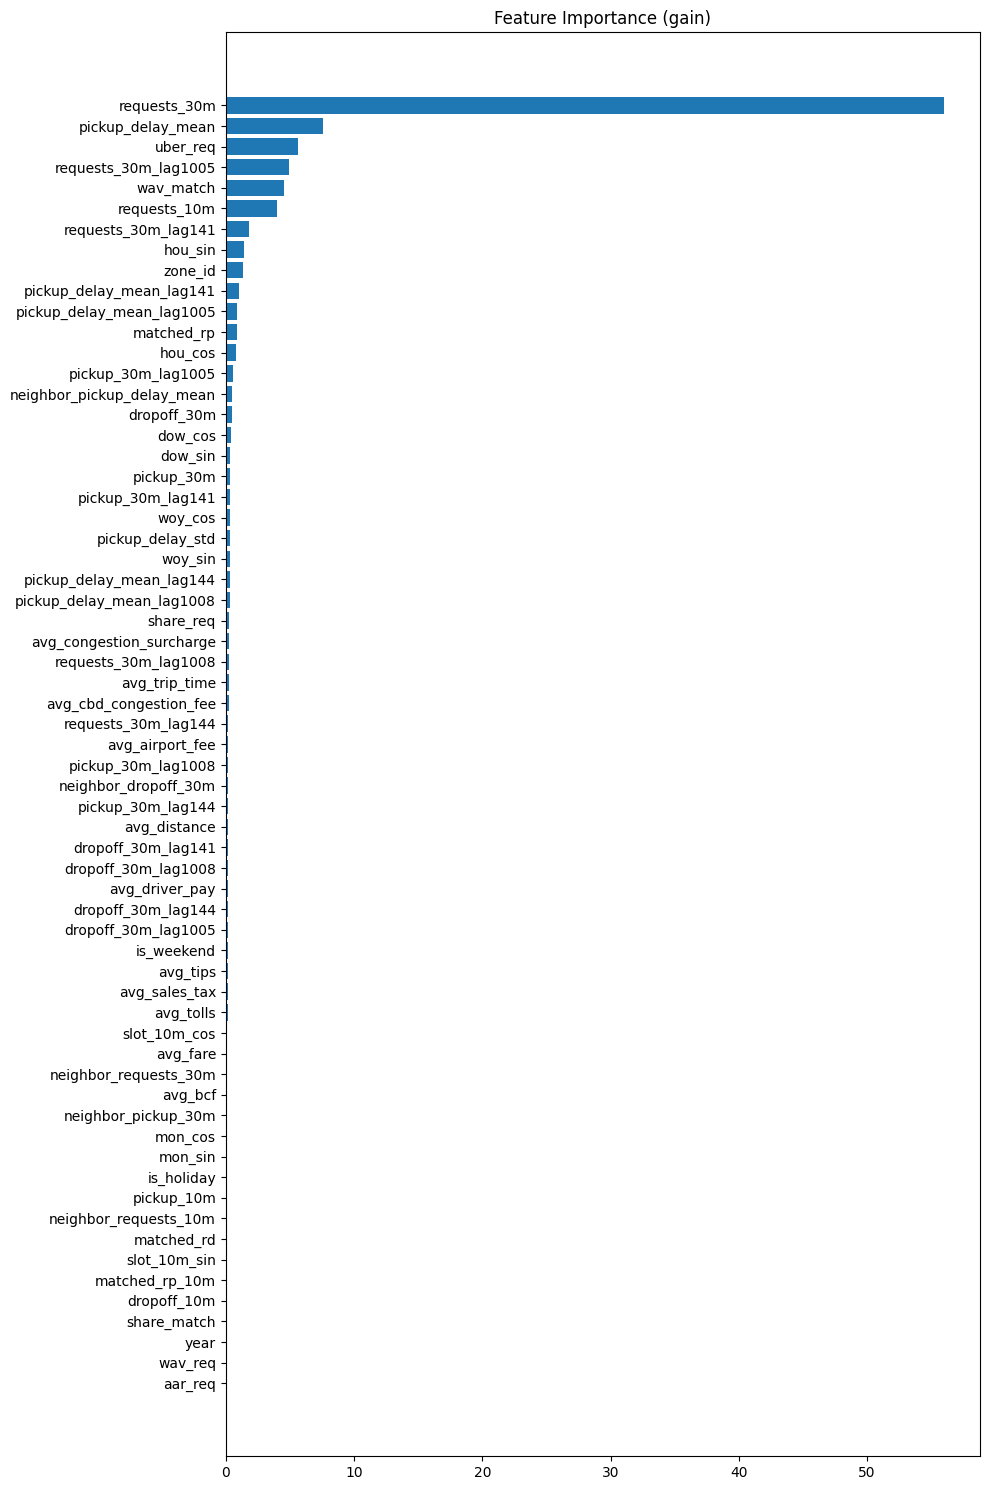

In [2]:
import matplotlib.pyplot as plt

fi_top = fi.head(80)

plt.figure(figsize=(10, 15))
plt.barh(fi_top["feature"], fi_top["importance_pct"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (gain)")
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

import lightgbm as lgb


# =========================
# 1. CONFIG
# =========================
DATA_PATH = r"C:\D\nam4_ki2\BigData\datasets\train_data\part-00047-89dd4d3a-f00b-47ff-8fae-20376af6ffd7-c000.snappy.parquet"
TARGET_COL = "label_7class"


# =========================
# 2. LOAD DATA
# =========================
def load_data(path):
    df = pd.read_parquet(path)

    X = df.drop(columns=[TARGET_COL,"window_end"])
    y = df[TARGET_COL]

    return X, y

# =========================
# 4. PREDICT
# =========================
def predict(model, X):
    # LightGBM trả về xác suất cho từng class
    y_prob = model.predict(X)

    # lấy class có xác suất cao nhất
    y_pred = np.argmax(y_prob, axis=1)

    return y_pred, y_prob


# =========================
# 5. EVALUATE
# =========================
def evaluate(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)

    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")

    precision_macro = precision_score(y_true, y_pred, average="macro")
    recall_macro = recall_score(y_true, y_pred, average="macro")

    print("===== METRICS =====")
    print(f"Accuracy       : {acc:.4f}")
    print(f"F1 (macro)     : {f1_macro:.4f}")
    print(f"F1 (weighted)  : {f1_weighted:.4f}")
    print(f"Precision      : {precision_macro:.4f}")
    print(f"Recall         : {recall_macro:.4f}")

    print("\n===== CLASSIFICATION REPORT =====")
    print(classification_report(y_true, y_pred))

    print("\n===== CONFUSION MATRIX =====")
    print(confusion_matrix(y_true, y_pred))


# =========================
# 6. MAIN
# =========================
def main():
    print("Loading data...")
    X, y = load_data(DATA_PATH)

    print("Loading model...")
    print("Predicting...")
    y_pred, _ = predict(model, X)

    print("Evaluating...")
    evaluate(y, y_pred)


if __name__ == "__main__":
    main()

Loading data...
Loading model...
Predicting...
Evaluating...
===== METRICS =====
Accuracy       : 0.7423
F1 (macro)     : 0.6910
F1 (weighted)  : 0.7441
Precision      : 0.6933
Recall         : 0.7005

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.47      0.68      0.56     19905
           1       0.76      0.71      0.74    124054
           2       0.80      0.79      0.79    208729
           3       0.71      0.72      0.71    103394
           4       0.66      0.74      0.69     32442
           5       0.76      0.57      0.65      9769

    accuracy                           0.74    498293
   macro avg       0.69      0.70      0.69    498293
weighted avg       0.75      0.74      0.74    498293


===== CONFUSION MATRIX =====
[[ 13539   5961     38      0      1    366]
 [ 13745  88509  21685     28      1     86]
 [    94  21155 163916  23486     75      3]
 [     0    100  19157  74492   9604     41]
 [     0   